Mounted at /content/drive


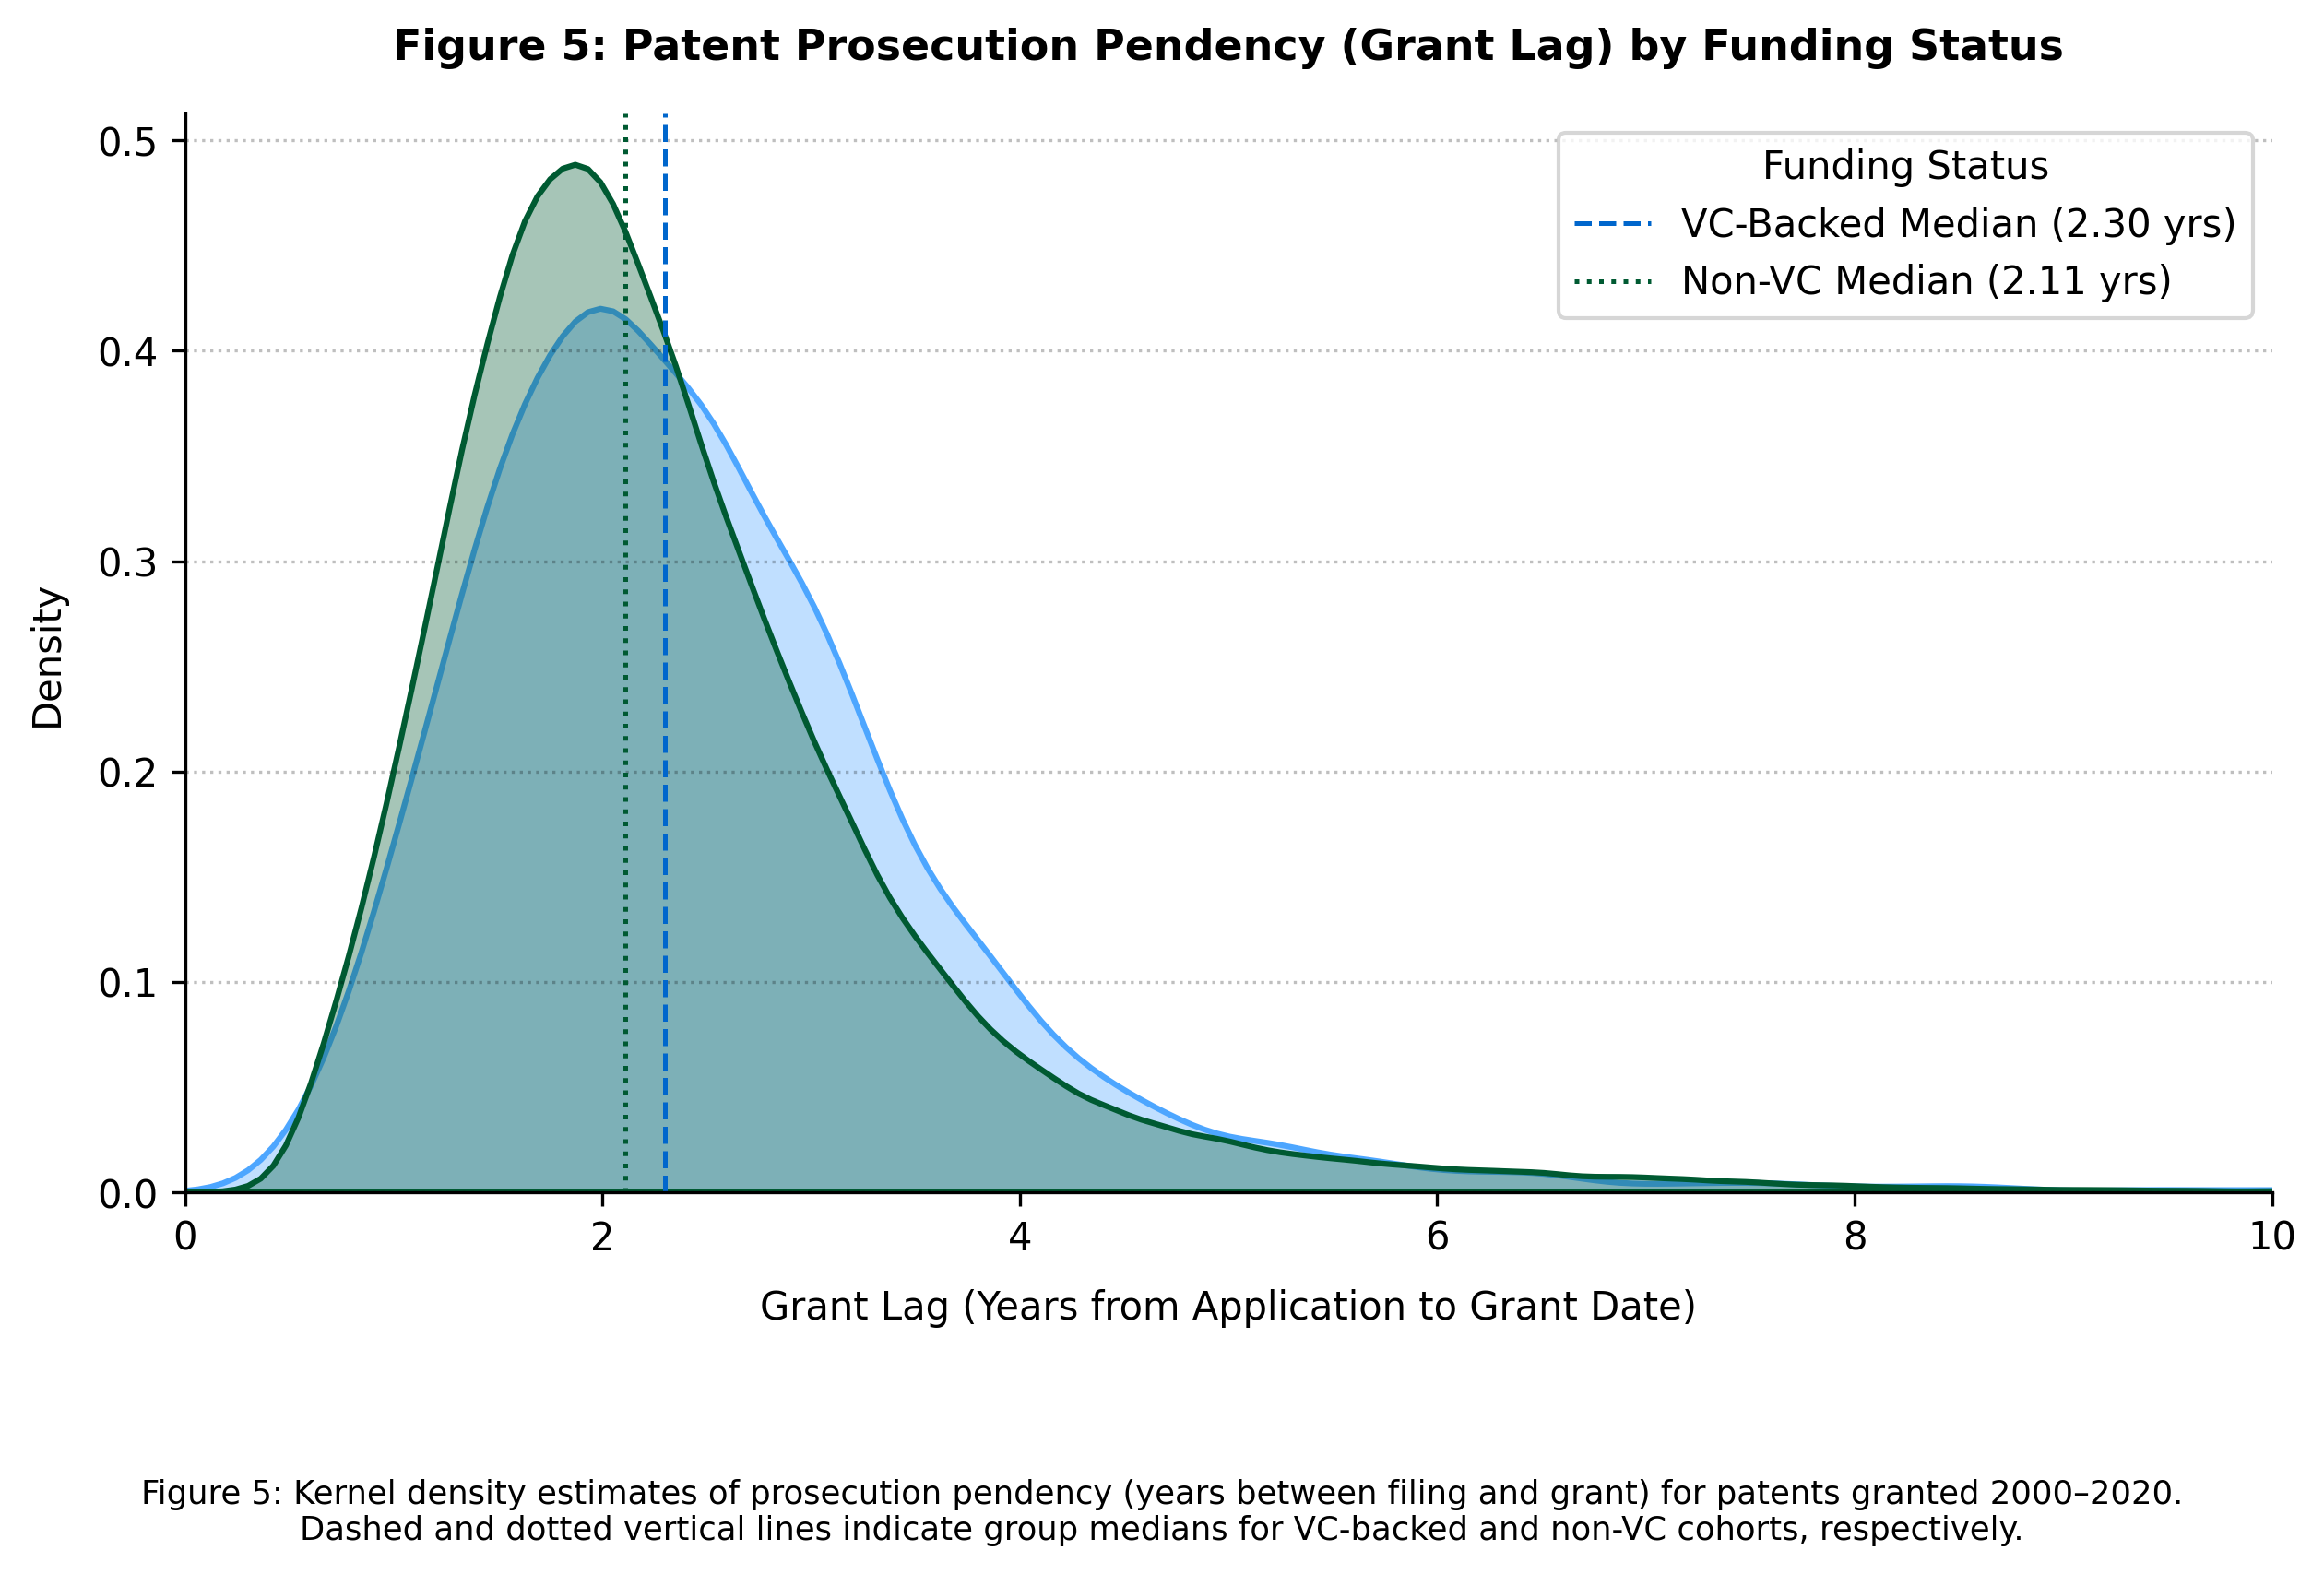

In [ ]:
#figure 5

import os
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

#functions
def load_grant_lag_data(parquet_file, start_year=2000, end_year=2020):
    con = duckdb.connect()
    df = con.execute(f"""
        SELECT
            CASE WHEN vc_backed = 1 THEN 'VC-Backed' ELSE 'Non-VC' END AS vc_status,
            DATEDIFF('day', application_date, grant_date) / 365.25 AS grant_lag_years
        FROM '{parquet_file}'
        WHERE application_date IS NOT NULL
          AND grant_date IS NOT NULL
          AND grant_date >= application_date
          AND grant_year BETWEEN {start_year} AND {end_year};
    """).df()
    return df

def configure_plot_style():
    plt.rcParams.update({
        'font.size': 10,
        'font.family': 'sans-serif',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.edgecolor': '#000000',
        'grid.color': '#000000',
        'grid.alpha': 0.25
    })

def plot_grant_lag_distribution(df, output_path):
    fig, ax = plt.subplots(figsize=(8.5, 5), dpi=300)

    #kde distribution
    sns.kdeplot(
        data=df,
        x='grant_lag_years',
        hue='vc_status',
        palette={'VC-Backed': '#4da6ff', 'Non-VC': '#005a32'},
        fill=True,
        common_norm=False,
        alpha=0.35,
        linewidth=1.5,
        clip=(0, 12),
        ax=ax
    )

    #medians
    vc_median = df[df['vc_status'] == 'VC-Backed']['grant_lag_years'].median()
    non_vc_median = df[df['vc_status'] == 'Non-VC']['grant_lag_years'].median()

    ax.axvline(vc_median, color='#0066cc', linestyle='--', linewidth=1.2, label=f'VC-Backed Median ({vc_median:.2f} yrs)')
    ax.axvline(non_vc_median, color='#005a32', linestyle=':', linewidth=1.2, label=f'Non-VC Median ({non_vc_median:.2f} yrs)')

    ax.set_title('Figure 5: Patent Prosecution Pendency (Grant Lag) by Funding Status', fontsize=11, fontweight='bold', pad=14)
    ax.set_xlabel('Grant Lag (Years from Application to Grant Date)', fontsize=10, labelpad=8)
    ax.set_ylabel('Density', fontsize=10, labelpad=8)
    ax.set_xlim(0, 10)
    ax.grid(True, linestyle=':', axis='y')

    ax.legend(title='Funding Status', frameon=True, loc='upper right')

    caption = (
        "Figure 5: Kernel density estimates of prosecution pendency (years between filing and grant) for patents granted 2000–2020.\n"
        "Dashed and dotted vertical lines indicate group medians for VC-backed and non-VC cohorts, respectively."
    )
    plt.figtext(0.5, -0.12, caption, wrap=True, horizontalalignment='center', fontsize=8.5, color='#000000')

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

#setup paths and load data
drive_mount_point = os.path.join(os.sep, "content", "drive")
drive.mount(drive_mount_point, force_remount=False)

drive_data_dir = os.path.join(drive_mount_point, "MyDrive", "data")
parquet_path = os.path.join(drive_data_dir, "cleaned_patent_panel.parquet")

df_lag = load_grant_lag_data(parquet_path, start_year=2000, end_year=2020)

#styling configuration and plot generation
configure_plot_style()
fig5_path = os.path.join(drive_data_dir, "figure5_grant_lag_distribution.png")
plot_grant_lag_distribution(df_lag, fig5_path)